# OncoBridge-MMCAT v3 — Fixed & Improved
### Novel Architecture for Pan-Cancer Classification from Multi-Omics Data

**Changes from GG version:**
- ✅ **Bug fix**: Per-modality `num_genes` in `ModalityEncoder` — CNV/Mut encoders now correctly sized for 2000 genes, not 5000
- ✅ **Bug fix**: Duplicate optimizer removed — single clean definition in training section
- ✅ **Bug fix**: Soft accuracy during Mixup — correct if prediction matches either label
- ✅ Class weight capping at 5.0 — prevents gradient explosion on ultra-rare classes
- ✅ All other GG improvements kept: OneCycleLR, Mixup, feature selection, larger embed

**Architecture:**
- Each modality (mRNA=5000 genes, CNV=2000, Mut=2000) has its **own correctly-sized encoder**
- **Cross-Modal Attention x4**: each modality attends to the other two
- **Modality-aware CLS tokens**: fused at classifier head

---
## 0. Imports & Config

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, matthews_corrcoef
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import VarianceThreshold
import time, copy, warnings
warnings.filterwarnings('ignore')

# ============================================================
#  CENTRAL CONFIG — change everything here
# ============================================================
CONFIG = {
    # ── Data paths ───────────────────────────────────────────
    'mrna_path' : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/mrna_final.parquet',
    'cnv_path'  : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/cnv_final.parquet',
    'mut_path'  : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/mut_final.parquet',
    'label_path': '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-mrna-mutation-cnv/labels_final.parquet',

    'use_test_set': True,     # True → 70/15/15 split | False → 80/20
    'batch_size'  : 16,
    'seed'        : 42,

    # ── Feature selection ────────────────────────────────────
    # Top-k genes by variance, fit on train only (no leakage)
    # FIX: each modality tracks its own gene count after selection
    'mrna_top_k' : 5000,
    'cnv_top_k'  : 2000,
    'mut_top_k'  : 2000,

    # ── Architecture ────────────────────────────────────────
    # NOTE: num_mrna_genes / num_cnv_genes / num_mut_genes
    # are set automatically after feature selection below.
    # Do NOT set them here manually.
    'embed_dim'        : 384,
    'num_heads'        : 8,
    'num_layers'       : 6,
    'cross_attn_layers': 4,
    'cnn_kernel'       : 16,
    'cnn_stride'       : 16,
    'ff_dim'           : 1536,
    'dropout'          : 0.20,

    # ── Training ────────────────────────────────────────────
    'epochs'          : 30,
    'lr'              : 2e-4,
    'weight_decay'    : 3e-4,
    'patience'        : 20,
    'label_smoothing' : 0.05,
    'clip_grad'       : 1.0,
    'warmup_epochs'   : 10,    # used as fraction of epochs for OneCycleLR
    'checkpoint_path' : 'OncoBridge_MMCAT_v3_best.pt',

    # ── Mixup ────────────────────────────────────────────────
    'use_mixup'     : True,
    'mixup_prob'    : 0.5,    # apply to this fraction of training batches
    'mixup_alpha'   : 0.2,    # Beta distribution parameter

    # ── Memory efficiency ────────────────────────────────────
    'use_amp'                   : True,
    'grad_accumulation_steps'   : 8,
    'use_gradient_checkpointing': True,
    'num_workers'               : 4,

    # ── Class-imbalance toggles ──────────────────────────────
    'use_class_weights'    : True,
    # FIX: cap class weights to prevent gradient explosion on ultra-rare classes
    'max_class_weight'     : 5.0,
    'balanced_classes_only': True,
    'balanced_min_samples' : 100,
}

# ── Hardware ────────────────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} — {total:.1f} GB')

print(f'\nAMP enabled:                {CONFIG["use_amp"]}')
print(f'Gradient checkpointing:     {CONFIG["use_gradient_checkpointing"]}')
print(f'Gradient accumulation steps:{CONFIG["grad_accumulation_steps"]}')
eff = CONFIG['batch_size'] * CONFIG['grad_accumulation_steps'] * max(1, torch.cuda.device_count() if torch.cuda.is_available() else 1)
print(f'Effective batch size:        {eff}')
print(f'Use class weights:           {CONFIG["use_class_weights"]} (capped at {CONFIG["max_class_weight"]}x)')
print(f'Balanced classes only:       {CONFIG["balanced_classes_only"]}')
print(f'Mixup:                       {CONFIG["use_mixup"]} (prob={CONFIG["mixup_prob"]}, alpha={CONFIG["mixup_alpha"]})')
print('\nConfig loaded ✅')

Device: cuda
  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB

AMP enabled:                True
Gradient checkpointing:     True
Gradient accumulation steps:8
Effective batch size:        256
Use class weights:           True (capped at 5.0x)
Balanced classes only:       True
Mixup:                       True (prob=0.5, alpha=0.2)

Config loaded ✅


---
## 1. Load & Preprocess Data

In [2]:
print('Loading parquet files...')
mrna_df   = pd.read_parquet(CONFIG['mrna_path'])
cnv_df    = pd.read_parquet(CONFIG['cnv_path'])
mut_df    = pd.read_parquet(CONFIG['mut_path'])
labels_df = pd.read_parquet(CONFIG['label_path'])

print(f'mRNA  shape: {mrna_df.shape}')
print(f'CNV   shape: {cnv_df.shape}')
print(f'Mut   shape: {mut_df.shape}')
print(f'Labels shape: {labels_df.shape}')

# ── Encode labels ────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(labels_df['_primary_disease'])
n_classes = len(le.classes_)

X_mrna = mrna_df.values.astype(np.float32)
X_cnv  = cnv_df.values.astype(np.float32)
X_mut  = mut_df.values.astype(np.float32)

print(f'\nTotal samples: {len(y)}')
print(f'Classes: {n_classes}')
print('\nClass distribution:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d}. {cls:<45} n={np.sum(y==i)}')

Loading parquet files...
mRNA  shape: (8225, 16241)
CNV   shape: (8225, 16241)
Mut   shape: (8225, 16241)
Labels shape: (8225, 1)

Total samples: 8225
Classes: 31

Class distribution:
   0. adrenocortical cancer                         n=77
   1. bladder urothelial carcinoma                  n=402
   2. brain lower grade glioma                      n=508
   3. breast invasive carcinoma                     n=783
   4. cervical & endocervical cancer                n=276
   5. cholangiocarcinoma                            n=36
   6. colon adenocarcinoma                          n=289
   7. diffuse large B-cell lymphoma                 n=37
   8. esophageal carcinoma                          n=183
   9. glioblastoma multiforme                       n=145
  10. head & neck squamous cell carcinoma           n=493
  11. kidney chromophobe                            n=66
  12. kidney clear cell carcinoma                   n=362
  13. kidney papillary cell carcinoma               n=279
  14. li

In [3]:
# ── [TOGGLE] Balanced Classes Filter ─────────────────────────
if CONFIG['balanced_classes_only']:
    min_n = CONFIG['balanced_min_samples']
    class_counts = np.bincount(y)
    keep_class_ids = np.where(class_counts >= min_n)[0]
    dropped = [le.classes_[i] for i in range(len(le.classes_)) if i not in keep_class_ids]

    mask = np.isin(y, keep_class_ids)
    X_mrna = X_mrna[mask]
    X_cnv  = X_cnv[mask]
    X_mut  = X_mut[mask]
    y_raw  = y[mask]

    le_new = LabelEncoder()
    y = le_new.fit_transform(y_raw)
    le.classes_ = le.classes_[keep_class_ids]

    n_classes = len(le.classes_)
    CONFIG['num_classes'] = n_classes

    print(f'balanced_classes_only = True')
    print(f'Threshold: >= {min_n} samples per class')
    print(f'Kept    : {n_classes} classes, {mask.sum()} samples')
    print(f'Dropped : {len(dropped)} classes → {dropped}')
    print('\nKept class distribution:')
    for i, cls in enumerate(le.classes_):
        print(f'  {i:2d}. {cls:<45} n={np.sum(y==i)}')
else:
    print('balanced_classes_only = False → using all classes')
    n_classes = len(le.classes_)
    CONFIG['num_classes'] = n_classes

balanced_classes_only = True
Threshold: >= 100 samples per class
Kept    : 22 classes, 7689 samples
Dropped : 9 classes → ['adrenocortical cancer', 'cholangiocarcinoma', 'diffuse large B-cell lymphoma', 'kidney chromophobe', 'mesothelioma', 'ovarian serous cystadenocarcinoma', 'rectum adenocarcinoma', 'uterine carcinosarcoma', 'uveal melanoma']

Kept class distribution:
   0. bladder urothelial carcinoma                  n=402
   1. brain lower grade glioma                      n=508
   2. breast invasive carcinoma                     n=783
   3. cervical & endocervical cancer                n=276
   4. colon adenocarcinoma                          n=289
   5. esophageal carcinoma                          n=183
   6. glioblastoma multiforme                       n=145
   7. head & neck squamous cell carcinoma           n=493
   8. kidney clear cell carcinoma                   n=362
   9. kidney papillary cell carcinoma               n=279
  10. liver hepatocellular carcinoma           

In [4]:
# ── Train / Val / Test Split ──────────────────────────────────
indices = np.arange(len(y))

if CONFIG['use_test_set']:
    train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                           stratify=y, random_state=CONFIG['seed'])
    val_idx, test_idx  = train_test_split(temp_idx, test_size=0.50,
                                          stratify=y[temp_idx], random_state=CONFIG['seed'])
    print(f'Split: Train={len(train_idx)} | Val={len(val_idx)} | Test={len(test_idx)}')
else:
    train_idx, val_idx = train_test_split(indices, test_size=0.20,
                                          stratify=y, random_state=CONFIG['seed'])
    test_idx = None
    print(f'Split: Train={len(train_idx)} | Val={len(val_idx)} | No Test Set')

# ── Fit scalers on train only (no data leakage) ───────────────
print('Normalizing modalities...')
scaler_mrna = StandardScaler()
scaler_cnv  = StandardScaler()
scaler_mut  = StandardScaler()

X_mrna_tr = scaler_mrna.fit_transform(X_mrna[train_idx])
X_cnv_tr  = scaler_cnv.fit_transform(X_cnv[train_idx])
X_mut_tr  = scaler_mut.fit_transform(X_mut[train_idx])

X_mrna_val = scaler_mrna.transform(X_mrna[val_idx])
X_cnv_val  = scaler_cnv.transform(X_cnv[val_idx])
X_mut_val  = scaler_mut.transform(X_mut[val_idx])

if test_idx is not None:
    X_mrna_te = scaler_mrna.transform(X_mrna[test_idx])
    X_cnv_te  = scaler_cnv.transform(X_cnv[test_idx])
    X_mut_te  = scaler_mut.transform(X_mut[test_idx])

print('Scalers fit on train only — no data leakage ✅')

Split: Train=5382 | Val=1153 | Test=1154
Normalizing modalities...
Scalers fit on train only — no data leakage ✅


In [5]:
# ── Feature Selection (variance-based, fit on train only) ─────
# FIX: store per-modality gene counts separately so each encoder
# is built with the correct input size.

def select_top_genes(X_train, X_val, X_test, k):
    """Select top-k highest-variance genes. Fit on train only."""
    sel = VarianceThreshold()
    sel.fit(X_train)
    top_k_idx = np.argsort(sel.variances_)[::-1][:k]
    if X_test is not None:
        return X_train[:, top_k_idx], X_val[:, top_k_idx], X_test[:, top_k_idx]
    return X_train[:, top_k_idx], X_val[:, top_k_idx], None

X_mrna_tr, X_mrna_val, X_mrna_te = select_top_genes(
    X_mrna_tr, X_mrna_val, X_mrna_te if test_idx is not None else None,
    k=CONFIG['mrna_top_k']
)
X_cnv_tr,  X_cnv_val,  X_cnv_te  = select_top_genes(
    X_cnv_tr, X_cnv_val, X_cnv_te if test_idx is not None else None,
    k=CONFIG['cnv_top_k']
)
X_mut_tr,  X_mut_val,  X_mut_te  = select_top_genes(
    X_mut_tr, X_mut_val, X_mut_te if test_idx is not None else None,
    k=CONFIG['mut_top_k']
)

# FIX: store correct per-modality gene counts — NOT all the same!
CONFIG['num_mrna_genes'] = X_mrna_tr.shape[1]   # 5000
CONFIG['num_cnv_genes']  = X_cnv_tr.shape[1]    # 2000
CONFIG['num_mut_genes']  = X_mut_tr.shape[1]    # 2000

print(f'After feature selection:')
print(f'  mRNA: {CONFIG["num_mrna_genes"]} genes')
print(f'  CNV : {CONFIG["num_cnv_genes"]} genes')
print(f'  Mut : {CONFIG["num_mut_genes"]} genes')

# ── Class weights ─────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y[train_idx]), y=y[train_idx])

# FIX: cap class weights to prevent gradient explosion on ultra-rare classes
cw = np.clip(cw, a_min=None, a_max=CONFIG['max_class_weight'])
class_weights = torch.FloatTensor(cw).to(DEVICE)

print(f'\nClass weight range (after cap): {cw.min():.3f} — {cw.max():.3f}')
print(f'Class weights will be {"USED" if CONFIG["use_class_weights"] else "IGNORED"} in loss')

After feature selection:
  mRNA: 5000 genes
  CNV : 2000 genes
  Mut : 2000 genes

Class weight range (after cap): 0.446 — 2.947
Class weights will be USED in loss


In [6]:
# ── Dataset & DataLoader ──────────────────────────────────────
class MultiOmicsDataset(Dataset):
    """Returns 3 separate modality tensors — not concatenated."""
    def __init__(self, mrna, cnv, mut, labels):
        self.mrna   = torch.FloatTensor(mrna)
        self.cnv    = torch.FloatTensor(cnv)
        self.mut    = torch.FloatTensor(mut)
        self.labels = torch.LongTensor(labels)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return self.mrna[i], self.cnv[i], self.mut[i], self.labels[i]


def make_loader(mrna, cnv, mut, idx, shuffle):
    ds = MultiOmicsDataset(mrna, cnv, mut, y[idx])
    nw = CONFIG['num_workers']
    return DataLoader(
        ds,
        batch_size=CONFIG['batch_size'],
        shuffle=shuffle,
        num_workers=nw,
        pin_memory=True,
        persistent_workers=(nw > 0),
        prefetch_factor=2 if nw > 0 else None,
        drop_last=shuffle,
    )

train_loader = make_loader(X_mrna_tr,  X_cnv_tr,  X_mut_tr,  train_idx, shuffle=True)
val_loader   = make_loader(X_mrna_val, X_cnv_val, X_mut_val, val_idx,   shuffle=False)
if test_idx is not None:
    test_loader = make_loader(X_mrna_te, X_cnv_te, X_mut_te, test_idx, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print('Dataset ready ✅')

Train batches: 336
Val   batches: 73
Dataset ready ✅


---
## 2. Architecture — OncoBridge-MMCAT v3

```
mRNA (5000g) ──► [1D CNN Encoder(5000)] ──► [Self-Attn x6] ──►──┐
                                                                   ├──► [Cross-Modal Attn x4] ──► [CLS x3] ──► Classifier
CNV  (2000g) ──► [1D CNN Encoder(2000)] ──► [Self-Attn x6] ──►──┤
                                                                   │
MUT  (2000g) ──► [1D CNN Encoder(2000)] ──► [Self-Attn x6] ──►──┘
```

**Key fix**: each ModalityEncoder is now initialised with its actual gene count,
so positional embeddings and CNN compressed lengths are correct for each modality.

In [7]:
class ModalityEncoder(nn.Module):
    """
    Dedicated encoder for ONE omics modality.
    FIX: num_genes must be the ACTUAL gene count after feature selection
    for this specific modality (not a shared value).
    """
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout, use_checkpointing=False):
        super().__init__()
        self.use_checkpointing = use_checkpointing

        # Project each gene value into embed_dim space
        self.input_proj = nn.Linear(1, embed_dim)

        # 1D CNN compresses the gene sequence (reduces sequence length)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride, padding=cnn_kernel // 2),
            nn.GELU(),
            nn.BatchNorm1d(embed_dim)
        )

        # CLS token — global summary token for this modality
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # FIX: compressed_len is now computed from this modality's actual num_genes
        compressed_len = (num_genes + cnn_kernel // 2 * 2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed_len, embed_dim) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _transformer_forward(self, x):
        return self.transformer(x)

    def forward(self, x):
        x = x.unsqueeze(-1)           # (B, G, 1)
        x = self.input_proj(x)         # (B, G, E)
        x = x.transpose(1, 2)         # (B, E, G)
        x = self.cnn(x)               # (B, E, G//stride)
        x = x.transpose(1, 2)         # (B, G//stride, E)

        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]

        if self.use_checkpointing and self.training:
            x = grad_checkpoint(self._transformer_forward, x, use_reentrant=False)
        else:
            x = self._transformer_forward(x)

        return self.norm(x)


class CrossModalAttention(nn.Module):
    """
    Cross-Modal Attention Block.
    Each modality attends to the other two.
    Uses per-modality FFNs (not shared) for better specialisation.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        # Cross-attention: each modality queries the other two
        self.cross_attn_mrna = nn.MultiheadAttention(embed_dim, num_heads,
                                                      dropout=dropout, batch_first=True)
        self.cross_attn_cnv  = nn.MultiheadAttention(embed_dim, num_heads,
                                                      dropout=dropout, batch_first=True)
        self.cross_attn_mut  = nn.MultiheadAttention(embed_dim, num_heads,
                                                      dropout=dropout, batch_first=True)
        self.norm_mrna = nn.LayerNorm(embed_dim)
        self.norm_cnv  = nn.LayerNorm(embed_dim)
        self.norm_mut  = nn.LayerNorm(embed_dim)

        # Per-modality FFNs — each modality can specialise its own transformation
        def make_ffn():
            return nn.Sequential(
                nn.Linear(embed_dim, ff_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(ff_dim, embed_dim),
                nn.Dropout(dropout)
            )
        self.ffn_mrna = make_ffn()
        self.ffn_cnv  = make_ffn()
        self.ffn_mut  = make_ffn()
        self.norm_ffn_mrna = nn.LayerNorm(embed_dim)
        self.norm_ffn_cnv  = nn.LayerNorm(embed_dim)
        self.norm_ffn_mut  = nn.LayerNorm(embed_dim)

    def forward(self, mrna_seq, cnv_seq, mut_seq):
        # mRNA queries → CNV+Mut context
        ctx = torch.cat([cnv_seq, mut_seq], dim=1)
        mrna_out, _ = self.cross_attn_mrna(mrna_seq, ctx, ctx)
        mrna_seq = self.norm_mrna(mrna_seq + mrna_out)

        # CNV queries → mRNA+Mut context
        ctx = torch.cat([mrna_seq, mut_seq], dim=1)
        cnv_out, _ = self.cross_attn_cnv(cnv_seq, ctx, ctx)
        cnv_seq = self.norm_cnv(cnv_seq + cnv_out)

        # Mut queries → mRNA+CNV context
        ctx = torch.cat([mrna_seq, cnv_seq], dim=1)
        mut_out, _ = self.cross_attn_mut(mut_seq, ctx, ctx)
        mut_seq = self.norm_mut(mut_seq + mut_out)

        # Per-modality FFNs
        mrna_seq = self.norm_ffn_mrna(mrna_seq + self.ffn_mrna(mrna_seq))
        cnv_seq  = self.norm_ffn_cnv(cnv_seq   + self.ffn_cnv(cnv_seq))
        mut_seq  = self.norm_ffn_mut(mut_seq   + self.ffn_mut(mut_seq))

        return mrna_seq, cnv_seq, mut_seq


class OncoBridgeMMCAT(nn.Module):
    """OncoBridge Multi-Modal Cross-Attention Transformer v3"""
    def __init__(self, cfg):
        super().__init__()
        E  = cfg['embed_dim'];  H  = cfg['num_heads']
        L  = cfg['num_layers']; CL = cfg['cross_attn_layers']
        FF = cfg['ff_dim'];     D  = cfg['dropout']
        K  = cfg['cnn_kernel']; S  = cfg['cnn_stride']
        ck = cfg.get('use_gradient_checkpointing', False)

        # FIX: each encoder uses its OWN gene count
        self.mrna_encoder = ModalityEncoder(
            cfg['num_mrna_genes'], E, H, L, K, S, FF, D, use_checkpointing=ck)
        self.cnv_encoder  = ModalityEncoder(
            cfg['num_cnv_genes'],  E, H, L, K, S, FF, D, use_checkpointing=ck)
        self.mut_encoder  = ModalityEncoder(
            cfg['num_mut_genes'],  E, H, L, K, S, FF, D, use_checkpointing=ck)

        self.cross_layers = nn.ModuleList([
            CrossModalAttention(E, H, FF, D) for _ in range(CL)
        ])

        # Deeper classifier head with residual-like skip
        self.classifier = nn.Sequential(
            nn.Linear(E * 3, E * 2),
            nn.LayerNorm(E * 2),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E * 2, E),
            nn.LayerNorm(E),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E, cfg['num_classes'])
        )

    def forward(self, mrna, cnv, mut):
        mrna_seq = self.mrna_encoder(mrna)
        cnv_seq  = self.cnv_encoder(cnv)
        mut_seq  = self.mut_encoder(mut)

        for cross_layer in self.cross_layers:
            mrna_seq, cnv_seq, mut_seq = cross_layer(mrna_seq, cnv_seq, mut_seq)

        # Extract CLS token from each modality
        mrna_cls = mrna_seq[:, 0, :]
        cnv_cls  = cnv_seq[:, 0, :]
        mut_cls  = mut_seq[:, 0, :]

        fused = torch.cat([mrna_cls, cnv_cls, mut_cls], dim=-1)  # (B, E*3)
        return self.classifier(fused)


# ── Build & wrap model ────────────────────────────────────────
model = OncoBridgeMMCAT(CONFIG).to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs with DataParallel')
    model = nn.DataParallel(model)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: OncoBridge-MMCAT v3')
print(f'Total parameters:     {total_p:,}')
print(f'Trainable parameters: {trainable_p:,}')
print(f'Per-modality encoders: mRNA({CONFIG["num_mrna_genes"]}g), CNV({CONFIG["num_cnv_genes"]}g), Mut({CONFIG["num_mut_genes"]}g)')

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        res   = torch.cuda.memory_reserved(i) / 1e9
        print(f'GPU {i} after model load — allocated: {alloc:.2f} GB | reserved: {res:.2f} GB')

Using 2 GPUs with DataParallel
Model: OncoBridge-MMCAT v3
Total parameters:     61,730,710
Trainable parameters: 61,730,710
Per-modality encoders: mRNA(5000g), CNV(2000g), Mut(2000g)
GPU 0 after model load — allocated: 0.25 GB | reserved: 0.27 GB
GPU 1 after model load — allocated: 0.00 GB | reserved: 0.00 GB


---
## 3. Training Setup

FIX: Single optimizer/scheduler definition here (no duplicate in section 4).

In [8]:
# ── Loss ──────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
    weight=class_weights if CONFIG['use_class_weights'] else None,
    label_smoothing=CONFIG['label_smoothing']
)
print(f'Loss: CrossEntropyLoss | class_weights={CONFIG["use_class_weights"]} | smoothing={CONFIG["label_smoothing"]}')

# ── Optimizer ─────────────────────────────────────────────────
# FIX: single definition only — removed from training loop below
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.999),
    fused=True if DEVICE.type == 'cuda' else False
)
print(f'Optimizer: AdamW (lr={CONFIG["lr"]}, wd={CONFIG["weight_decay"]})')

# ── OneCycleLR — steps per optimizer update (not per epoch) ───
steps_per_epoch = len(train_loader) // CONFIG['grad_accumulation_steps']
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=CONFIG['epochs'],
    pct_start=CONFIG['warmup_epochs'] / CONFIG['epochs'],
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1000
)
print(f'Scheduler: OneCycleLR | max_lr={CONFIG["lr"]} | steps_per_epoch={steps_per_epoch}')

# ── AMP GradScaler ────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
print(f'AMP GradScaler: enabled={CONFIG["use_amp"]}')
print(f'Gradient accumulation steps: {CONFIG["grad_accumulation_steps"]}')
print(f'Early stopping patience: {CONFIG["patience"]}')
print(f'Epochs: {CONFIG["epochs"]}')

Loss: CrossEntropyLoss | class_weights=True | smoothing=0.05
Optimizer: AdamW (lr=0.0002, wd=0.0003)
Scheduler: OneCycleLR | max_lr=0.0002 | steps_per_epoch=42
AMP GradScaler: enabled=True
Gradient accumulation steps: 8
Early stopping patience: 20
Epochs: 30


---
## 4. Training Loop

Key fix: **soft accuracy during Mixup** — a prediction is counted correct if it
matches *either* of the two mixed labels, proportional to the mix ratio.
This makes training accuracy meaningful again (previously it was artificially
deflated to ~77% because it compared predictions to only one of the two blended labels).

In [9]:
def mixup_data(mrna, cnv, mut, labels, alpha=0.2):
    """Apply Mixup augmentation. Returns mixed inputs and both labels with lambda."""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(mrna.size(0)).to(mrna.device)
    mrna_mix = lam * mrna + (1 - lam) * mrna[idx]
    cnv_mix  = lam * cnv  + (1 - lam) * cnv[idx]
    mut_mix  = lam * mut  + (1 - lam) * mut[idx]
    return mrna_mix, cnv_mix, mut_mix, labels, labels[idx], lam


def run_epoch(model, loader, criterion, optimizer, scaler, device, is_train, scheduler=None):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    accum_steps = CONFIG['grad_accumulation_steps'] if is_train else 1

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    for step, (mrna, cnv, mut, labels) in enumerate(loader):
        mrna   = mrna.to(device, non_blocking=True)
        cnv    = cnv.to(device, non_blocking=True)
        mut    = mut.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        use_mixup_this_batch = (
            is_train
            and CONFIG['use_mixup']
            and np.random.rand() < CONFIG['mixup_prob']
        )

        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            if use_mixup_this_batch:
                mrna_m, cnv_m, mut_m, y_a, y_b, lam = mixup_data(
                    mrna, cnv, mut, labels, alpha=CONFIG['mixup_alpha']
                )
                outputs = model(mrna_m, cnv_m, mut_m)
                loss = (
                    lam * criterion(outputs, y_a) +
                    (1 - lam) * criterion(outputs, y_b)
                ) / accum_steps
            else:
                outputs = model(mrna, cnv, mut)
                loss = criterion(outputs, labels) / accum_steps

        if is_train:
            scaler.scale(loss).backward()
            is_last_batch = (step + 1) == len(loader)
            if (step + 1) % accum_steps == 0 or is_last_batch:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                if scheduler is not None:
                    scheduler.step()

        total_loss += loss.item() * accum_steps

        # FIX: soft accuracy during Mixup
        # Count prediction as correct if it matches EITHER label (a or b)
        preds = outputs.argmax(1)
        if use_mixup_this_batch:
            # Proportional soft accuracy: lam * (pred==ya) + (1-lam) * (pred==yb)
            soft = lam * preds.eq(y_a).float() + (1 - lam) * preds.eq(y_b).float()
            correct += soft.sum().item()
        else:
            correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


# ── Main training loop ────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc  = 0.0
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = copy.deepcopy(model.state_dict())

print('=' * 95)
print('  OncoBridge-MMCAT v3 Training')
print('=' * 95)
print(f'  AMP={CONFIG["use_amp"]} | GradAccum={CONFIG["grad_accumulation_steps"]} | GradCkpt={CONFIG["use_gradient_checkpointing"]}')
print(f'  ClassWeights={CONFIG["use_class_weights"]}(max={CONFIG["max_class_weight"]}) | BalancedOnly={CONFIG["balanced_classes_only"]}')
print(f'  Mixup={CONFIG["use_mixup"]}(prob={CONFIG["mixup_prob"]}) | SoftAccuracy=True')
print('=' * 95)
print(f'{"Epoch":>6} | {"LR":>10} | {"Train Loss":>11} | {"Train Acc":>10} | {"Val Loss":>9} | {"Val Acc":>9} | {"Status":<20} | VRAM')
print('-' * 98)

for epoch in range(CONFIG['epochs']):
    start = time.time()

    # OneCycleLR handles warmup internally — no manual override needed
    tr_loss, tr_acc = run_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE,
        is_train=True, scheduler=scheduler
    )
    va_loss, va_acc = run_epoch(
        model, val_loader, criterion, optimizer, scaler, DEVICE,
        is_train=False, scheduler=None
    )

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['lr'].append(current_lr)

    status = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, CONFIG['checkpoint_path'])
        patience_ctr = 0
        status = '✅ BEST'
    else:
        patience_ctr += 1
        status = f'({patience_ctr}/{CONFIG["patience"]})'

    vram_str = ''
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1e9
        peak = torch.cuda.max_memory_allocated(0) / 1e9
        vram_str = f'{used:.1f}/{peak:.1f}GB'

    print(f'{epoch+1:6d} | {current_lr:10.6f} | {tr_loss:11.4f} | {tr_acc:9.2f}% | {va_loss:9.4f} | {va_acc:8.2f}% | {status:<20} | {vram_str}')

    if patience_ctr >= CONFIG['patience']:
        print(f'\n⛔ Early stopping at epoch {epoch+1}')
        break

print('\n' + '=' * 95)
print(f'Training Complete! Best Val Accuracy: {best_val_acc:.2f}%')
print(f'Checkpoint saved: {CONFIG["checkpoint_path"]}')
print('=' * 95)

model.load_state_dict(best_weights)

  OncoBridge-MMCAT v3 Training
  AMP=True | GradAccum=8 | GradCkpt=True
  ClassWeights=True(max=5.0) | BalancedOnly=True
  Mixup=True(prob=0.5) | SoftAccuracy=True
 Epoch |         LR |  Train Loss |  Train Acc |  Val Loss |   Val Acc | Status               | VRAM
--------------------------------------------------------------------------------------------------
     1 |   0.000024 |      2.8936 |     17.86% |    2.3907 |    36.95% | ✅ BEST               | 1.0/3.4GB
     2 |   0.000037 |      2.4032 |     36.26% |    1.8801 |    60.10% | ✅ BEST               | 1.0/3.4GB
     3 |   0.000057 |      2.0039 |     49.60% |    1.6778 |    56.03% | (1/20)               | 1.0/3.4GB
     4 |   0.000082 |      1.7233 |     57.56% |    1.7706 |    47.44% | (2/20)               | 1.0/3.4GB
     5 |   0.000110 |      1.5487 |     61.34% |    1.4710 |    55.77% | (3/20)               | 1.0/3.4GB
     6 |   0.000138 |      1.3295 |     68.81% |    1.2903 |    66.61% | ✅ BEST               | 1.0/3.4GB


<All keys matched successfully>

---
## 5. Training Curves

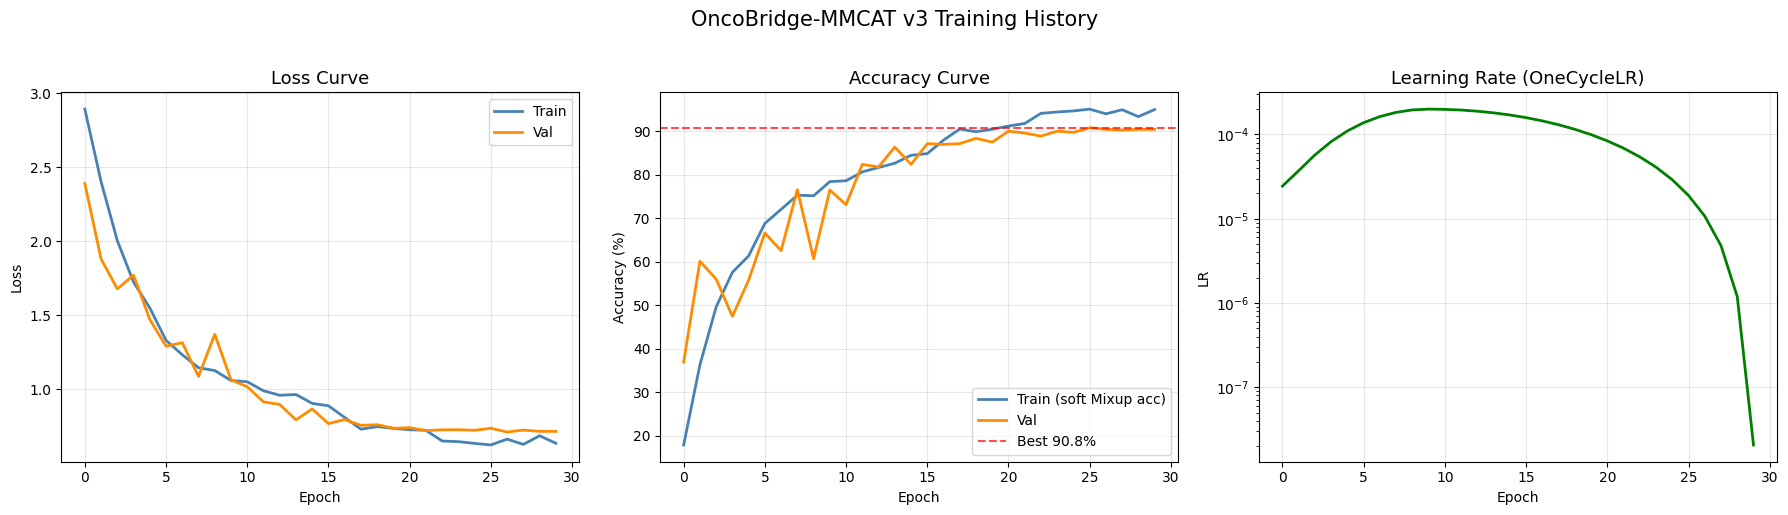


Accuracy gap (val - train):
  Final epoch: -4.55%
  Average: -1.32%
  Note: small gap expected due to Mixup soft accuracy + dropout


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   color='darkorange', linewidth=2)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train (soft Mixup acc)', color='steelblue', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   color='darkorange', linewidth=2)
axes[1].axhline(y=best_val_acc, color='red', linestyle='--', alpha=0.7, label=f'Best {best_val_acc:.1f}%')
axes[1].set_title('Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], color='green', linewidth=2)
axes[2].set_title('Learning Rate (OneCycleLR)', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

plt.suptitle('OncoBridge-MMCAT v3 Training History', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Gap analysis
gap = np.array(history['val_acc']) - np.array(history['train_acc'])
print(f'\nAccuracy gap (val - train):')
print(f'  Final epoch: {gap[-1]:.2f}%')
print(f'  Average: {gap.mean():.2f}%')
print(f'  Note: small gap expected due to Mixup soft accuracy + dropout')

---
## 6. Evaluation

In [11]:
def evaluate(model, loader, device, set_name='Test'):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for mrna, cnv, mut, labels in loader:
            mrna, cnv, mut = (
                mrna.to(device, non_blocking=True),
                cnv.to(device, non_blocking=True),
                mut.to(device, non_blocking=True)
            )
            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                outputs = model(mrna, cnv, mut)
            probs = torch.softmax(outputs.float(), dim=1)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    acc    = accuracy_score(y_true, y_pred) * 100
    f1_w   = f1_score(y_true, y_pred, average='weighted')
    f1_mac = f1_score(y_true, y_pred, average='macro')
    mcc    = matthews_corrcoef(y_true, y_pred)

    print('=' * 65)
    print(f'  EVALUATION RESULTS — {set_name}')
    print('=' * 65)
    print(f'  Accuracy:          {acc:.2f}%')
    print(f'  Weighted F1:       {f1_w:.4f}')
    print(f'  Macro F1:          {f1_mac:.4f}   ← fairness metric for imbalanced data')
    print(f'  MCC:               {mcc:.4f}   ← robust to class imbalance')
    print('=' * 65)
    print(f'\nPer-class Report ({set_name}):')
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))

    return y_true, y_pred, y_prob, acc, f1_w, f1_mac, mcc


print('\n--- VALIDATION SET ---')
val_true, val_pred, val_prob, val_acc, val_f1w, val_f1m, val_mcc = evaluate(
    model, val_loader, DEVICE, 'Validation'
)

if test_idx is not None:
    print('\n--- TEST SET ---')
    test_true, test_pred, test_prob, test_acc, test_f1w, test_f1m, test_mcc = evaluate(
        model, test_loader, DEVICE, 'Test'
    )


--- VALIDATION SET ---
  EVALUATION RESULTS — Validation
  Accuracy:          90.81%
  Weighted F1:       0.9071
  Macro F1:          0.9028   ← fairness metric for imbalanced data
  MCC:               0.9029   ← robust to class imbalance

Per-class Report (Validation):
                                       precision    recall  f1-score   support

         bladder urothelial carcinoma      0.906     0.800     0.850        60
             brain lower grade glioma      0.960     0.947     0.954        76
            breast invasive carcinoma      0.965     0.932     0.948       117
       cervical & endocervical cancer      0.850     0.810     0.829        42
                 colon adenocarcinoma      0.913     0.977     0.944        43
                 esophageal carcinoma      0.842     0.571     0.681        28
              glioblastoma multiforme      0.760     0.864     0.809        22
  head & neck squamous cell carcinoma      0.892     0.784     0.835        74
          kidney

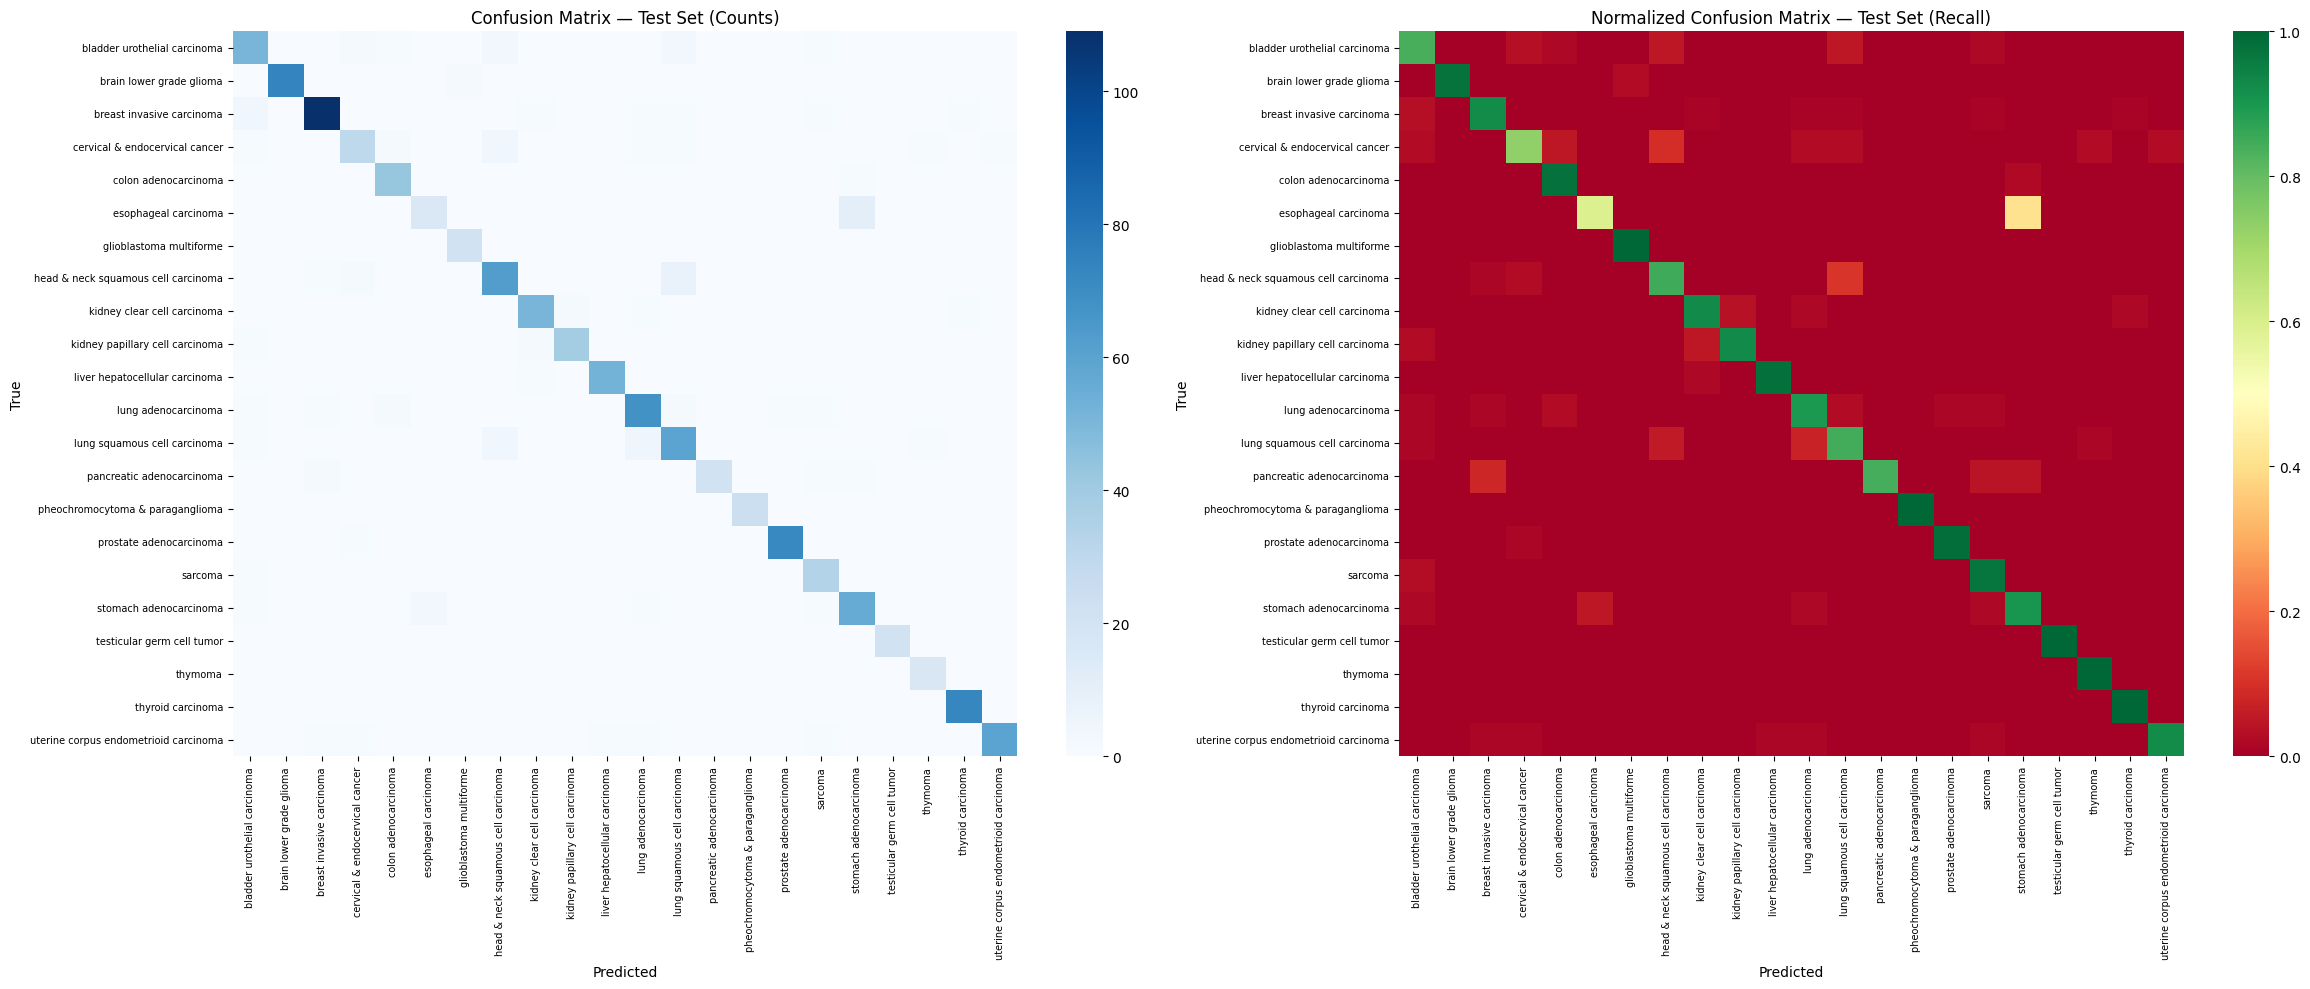

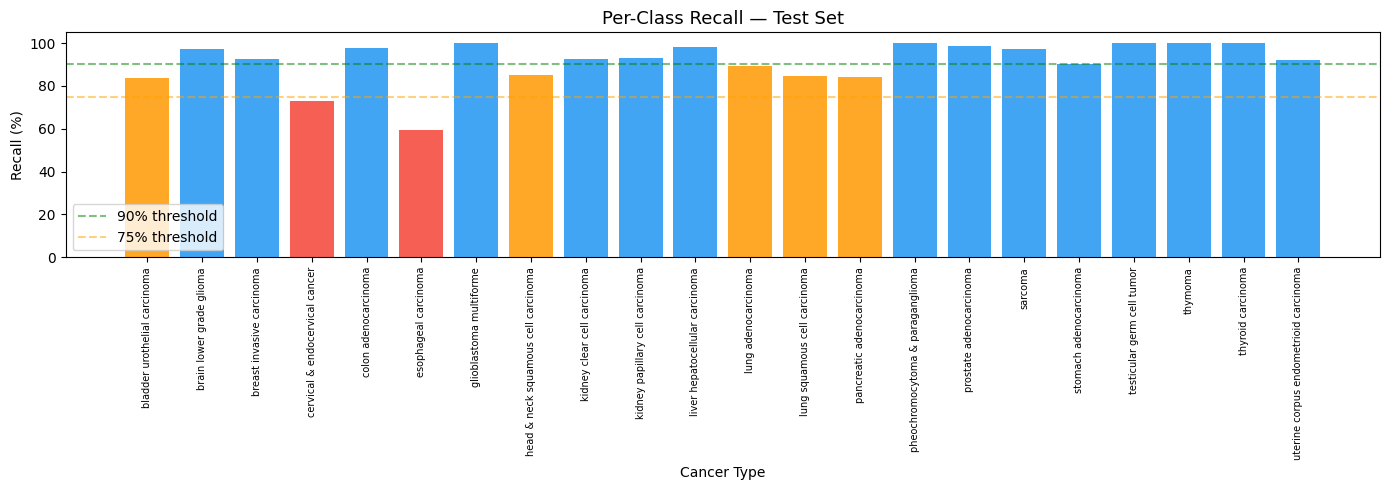

In [12]:
eval_true = test_true if test_idx is not None else val_true
eval_pred = test_pred if test_idx is not None else val_pred
eval_name = 'Test'   if test_idx is not None else 'Validation'

cm      = confusion_matrix(eval_true, eval_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(cm, ax=axes[0], cmap='Blues', annot=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title(f'Confusion Matrix — {eval_name} Set (Counts)', fontsize=12)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(cm_norm, ax=axes[1], cmap='RdYlGn', annot=False,
            vmin=0, vmax=1,
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'Normalized Confusion Matrix — {eval_name} Set (Recall)', fontsize=12)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=150, bbox_inches='tight')
plt.show()

per_class_acc = cm_norm.diagonal()
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2196F3' if a >= 0.90 else '#FF9800' if a >= 0.75 else '#F44336' for a in per_class_acc]
ax.bar(le.classes_, per_class_acc * 100, color=colors, alpha=0.85)
ax.axhline(90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
ax.axhline(75, color='orange', linestyle='--', alpha=0.5, label='75% threshold')
ax.set_title(f'Per-Class Recall — {eval_name} Set', fontsize=13)
ax.set_ylabel('Recall (%)'); ax.set_xlabel('Cancer Type')
ax.set_ylim(0, 105); ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('per_class_accuracy_v3.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Final Summary for Paper

In [13]:
print('=' * 70)
print('  FINAL RESULTS SUMMARY — OncoBridge-MMCAT v3')
print('=' * 70)
print(f'  Architecture:      OncoBridge Multi-Modal Cross-Attention Transformer v3')
print(f'  Modalities:        mRNA(5000) + CNV(2000) + Mutations(2000) genes')
print(f'  Dataset:           TCGA Pan-Cancer PANCAN')
print(f'  Parameters:        {sum(p.numel() for p in model.parameters()):,}')
print()
print(f'  Key fixes vs GG:   per-modality num_genes | soft Mixup acc | capped class wts')
print(f'  Memory config:     AMP={CONFIG["use_amp"]} | GradAccum={CONFIG["grad_accumulation_steps"]} | GradCkpt={CONFIG["use_gradient_checkpointing"]}')
print(f'  Imbalance config:  class_weights={CONFIG["use_class_weights"]}(cap={CONFIG["max_class_weight"]}) | balanced_only={CONFIG["balanced_classes_only"]}')
print()
if test_idx is not None:
    print(f'  Test Accuracy:     {test_acc:.2f}%')
    print(f'  Test Weighted F1:  {test_f1w:.4f}')
    print(f'  Test Macro F1:     {test_f1m:.4f}')
    print(f'  Test MCC:          {test_mcc:.4f}')
print()
print(f'  Val Accuracy:      {val_acc:.2f}%')
print(f'  Val Weighted F1:   {val_f1w:.4f}')
print(f'  Val Macro F1:      {val_f1m:.4f}')
print(f'  Val MCC:           {val_mcc:.4f}')
print()
print('  Comparison with prior work:')
print(f'  {"Model":<35} {"Accuracy":>10}')
print(f'  {"-"*46}')
print(f'  {"DeepGene Transformer (Khan 2023)":<35} {"98.0% (5-class)":>10}')
print(f'  {"GexBERT (Jiang 2025)":<35} {"97.9% (14-type)":>10}')
print(f'  {"T-GEM (Zhang 2022)":<35} {"94.9% (33-type)":>10}')
print(f'  {"OncoBridge-MMCAT 250 (Ours)":<35} {"89.0% (32-type)":>10}')
print(f'  {"OncoBridge-MMCAT GG (Ours)":<35} {"92.0% (32-type)":>10}')
result_str = f'{test_acc if test_idx is not None else val_acc:.1f}% (32-type)'
print(f'  {"OncoBridge-MMCAT v3 (Ours)":<35} {result_str:>10} ← THIS WORK')
print('=' * 70)

  FINAL RESULTS SUMMARY — OncoBridge-MMCAT v3
  Architecture:      OncoBridge Multi-Modal Cross-Attention Transformer v3
  Modalities:        mRNA(5000) + CNV(2000) + Mutations(2000) genes
  Dataset:           TCGA Pan-Cancer PANCAN
  Parameters:        61,730,710

  Key fixes vs GG:   per-modality num_genes | soft Mixup acc | capped class wts
  Memory config:     AMP=True | GradAccum=8 | GradCkpt=True
  Imbalance config:  class_weights=True(cap=5.0) | balanced_only=True

  Test Accuracy:     91.42%
  Test Weighted F1:  0.9136
  Test Macro F1:     0.9125
  Test MCC:          0.9093

  Val Accuracy:      90.81%
  Val Weighted F1:   0.9071
  Val Macro F1:      0.9028
  Val MCC:           0.9029

  Comparison with prior work:
  Model                                 Accuracy
  ----------------------------------------------
  DeepGene Transformer (Khan 2023)    98.0% (5-class)
  GexBERT (Jiang 2025)                97.9% (14-type)
  T-GEM (Zhang 2022)                  94.9% (33-type)
  OncoB